In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import logit, expit
from sklearn import metrics

import pandas as pd
import seaborn as sns

import os

(AUC) : 0.9909
Threshold computed   : 0.6893
At threshold    : TPR=0.98, FPR=0.07
FNR=0.02


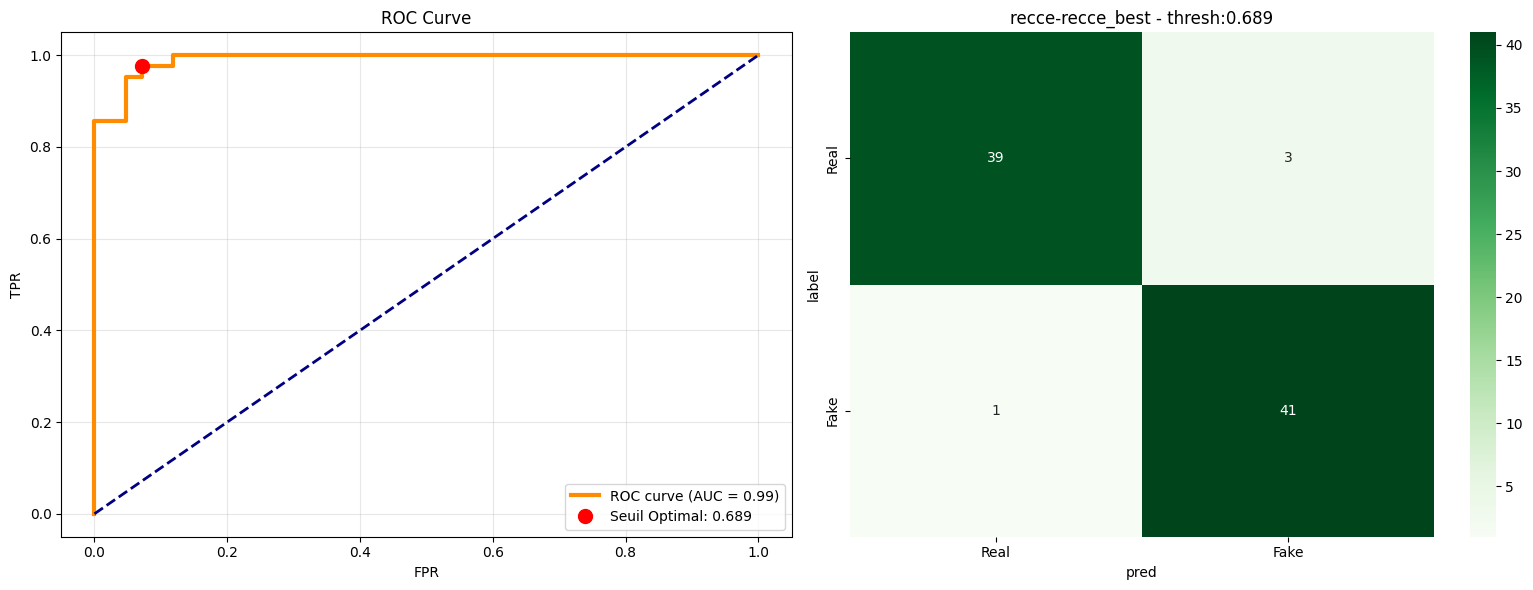

(AUC) : 0.9663
Threshold computed   : 0.6223
At threshold    : TPR=0.95, FPR=0.10
FNR=0.05


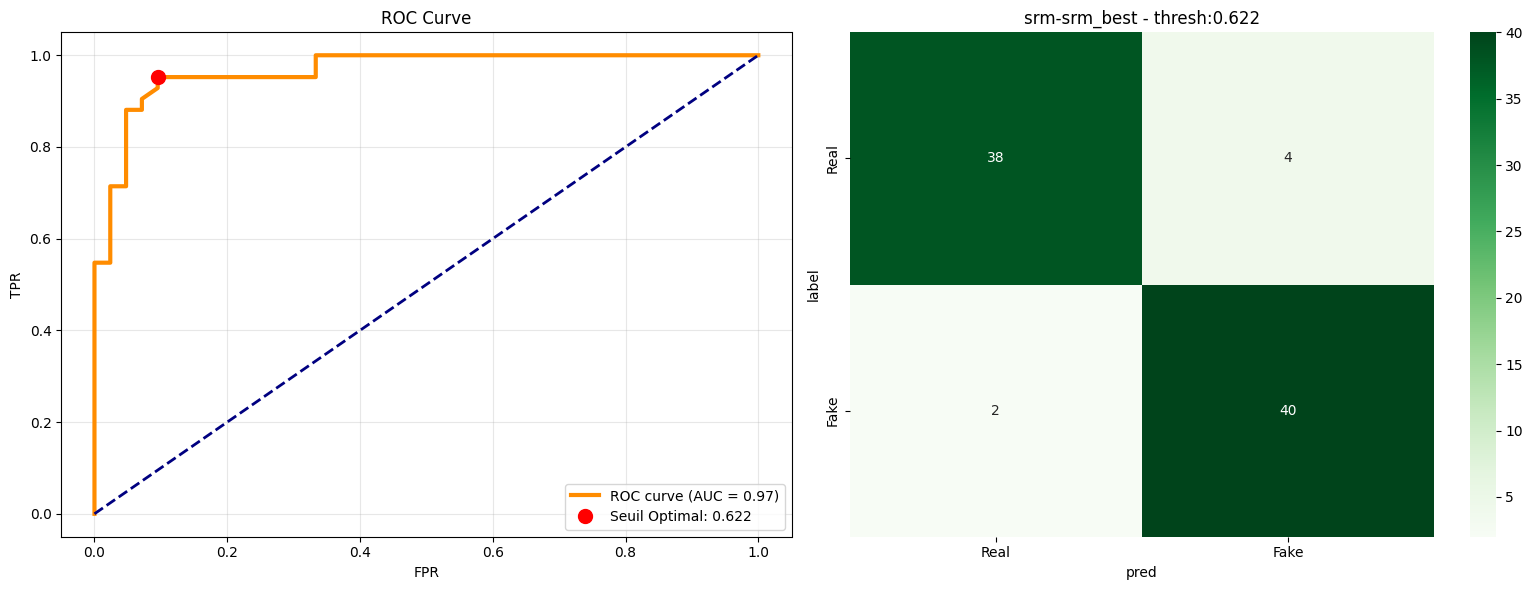

(AUC) : 0.9742
Threshold computed   : 0.9572
At threshold    : TPR=0.88, FPR=0.00
FNR=0.12


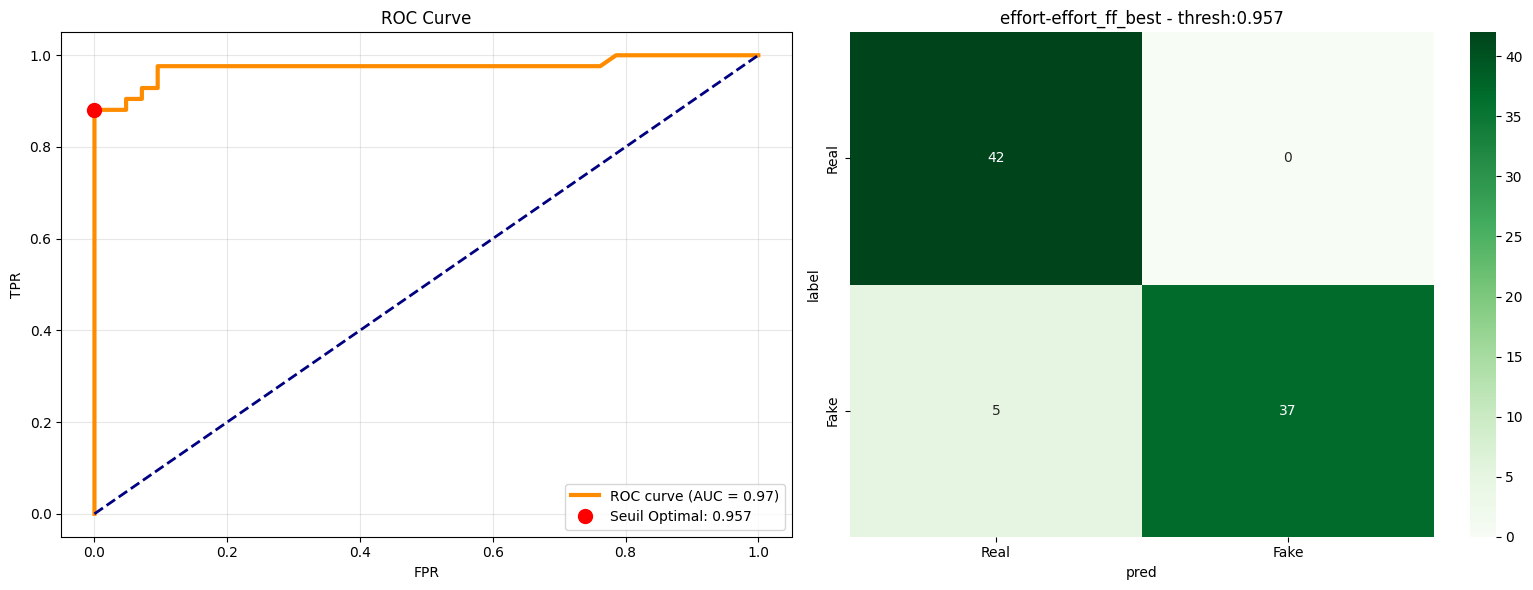

(AUC) : 0.9861
Threshold computed   : 0.8419
At threshold    : TPR=0.95, FPR=0.05
FNR=0.05


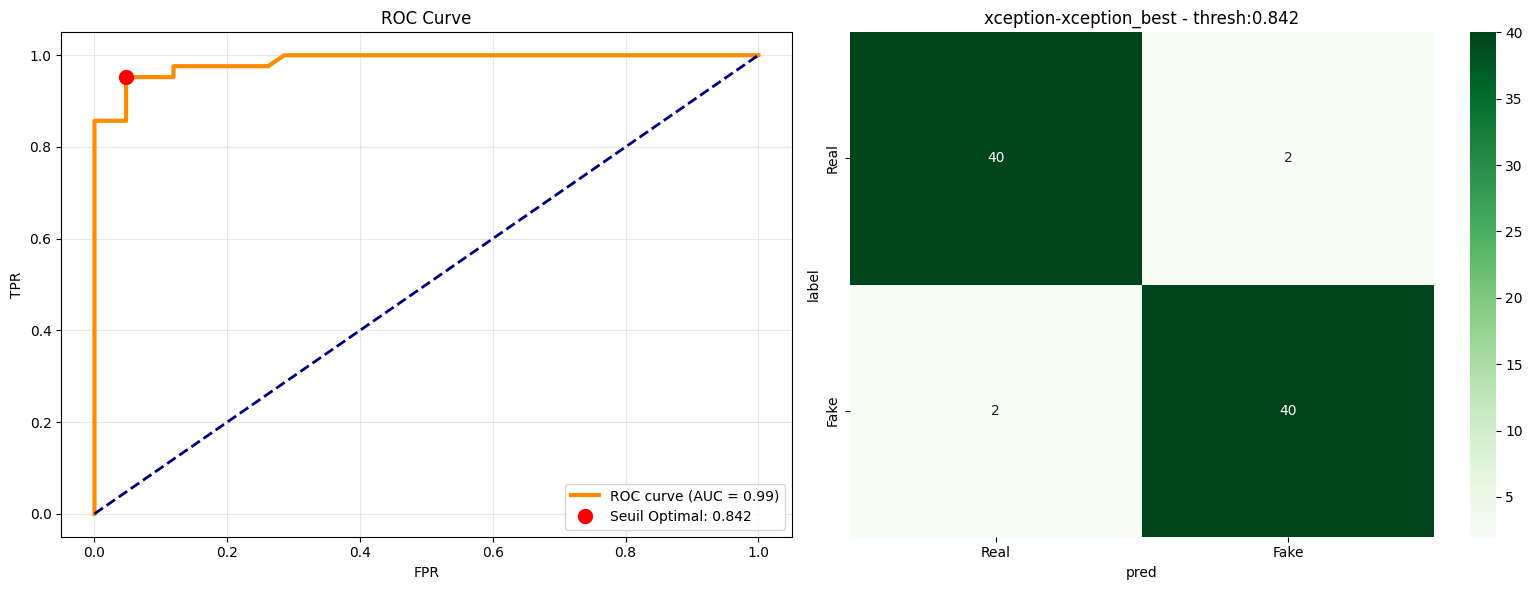

(AUC) : 0.9527
Threshold computed   : 0.9952
At threshold    : TPR=0.88, FPR=0.07
FNR=0.12


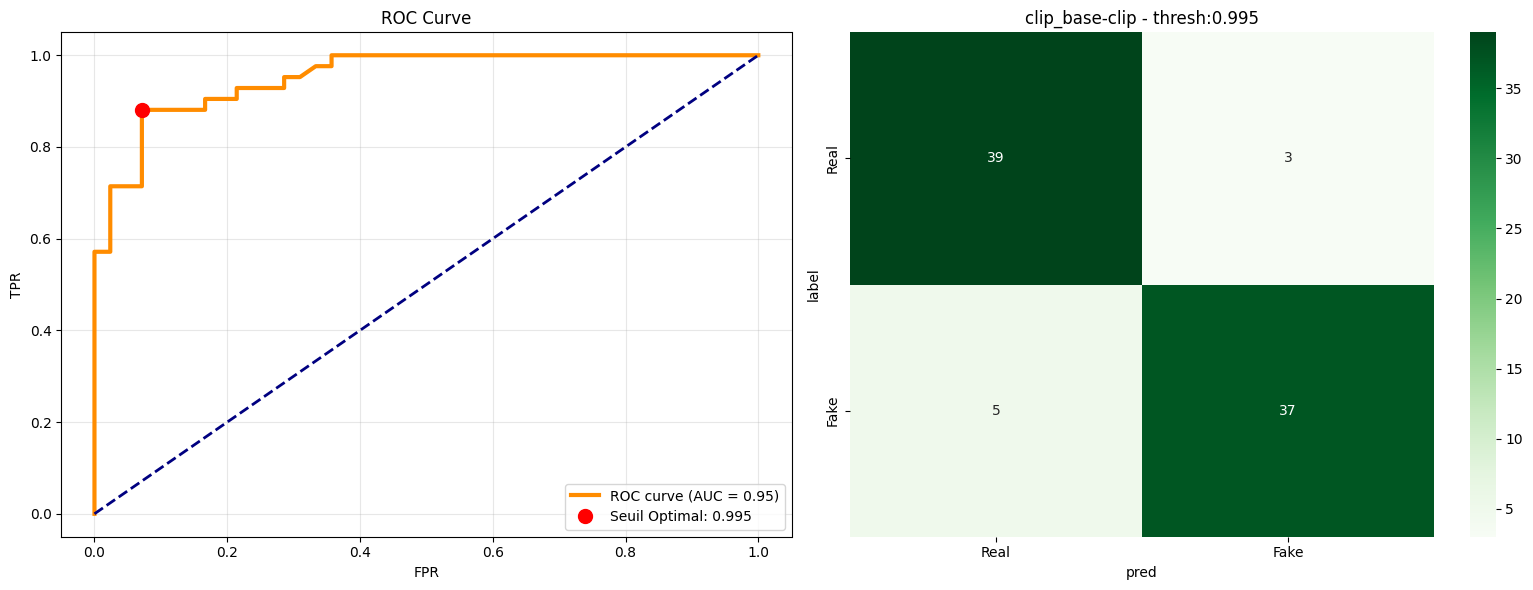

(AUC) : 0.9821
Threshold computed   : 0.6906
At threshold    : TPR=0.98, FPR=0.07
FNR=0.02


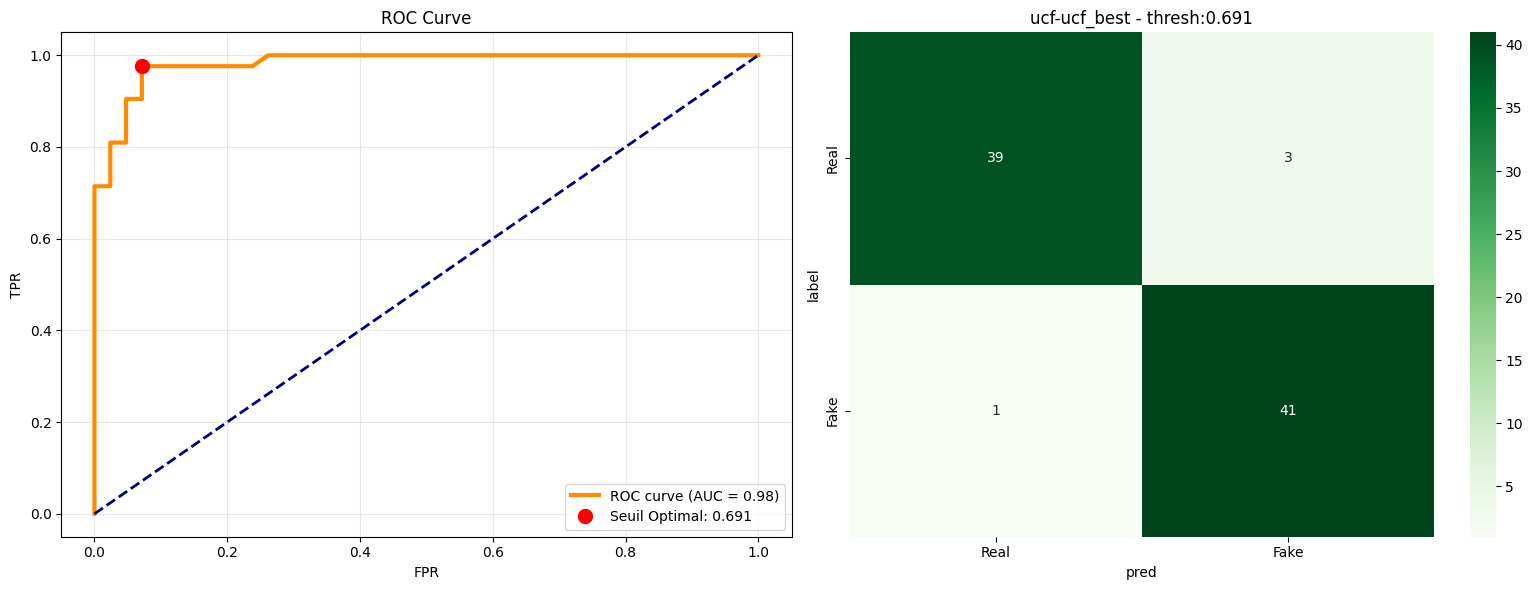

(AUC) : 0.9722
Threshold computed   : 0.9911
At threshold    : TPR=0.93, FPR=0.07
FNR=0.07


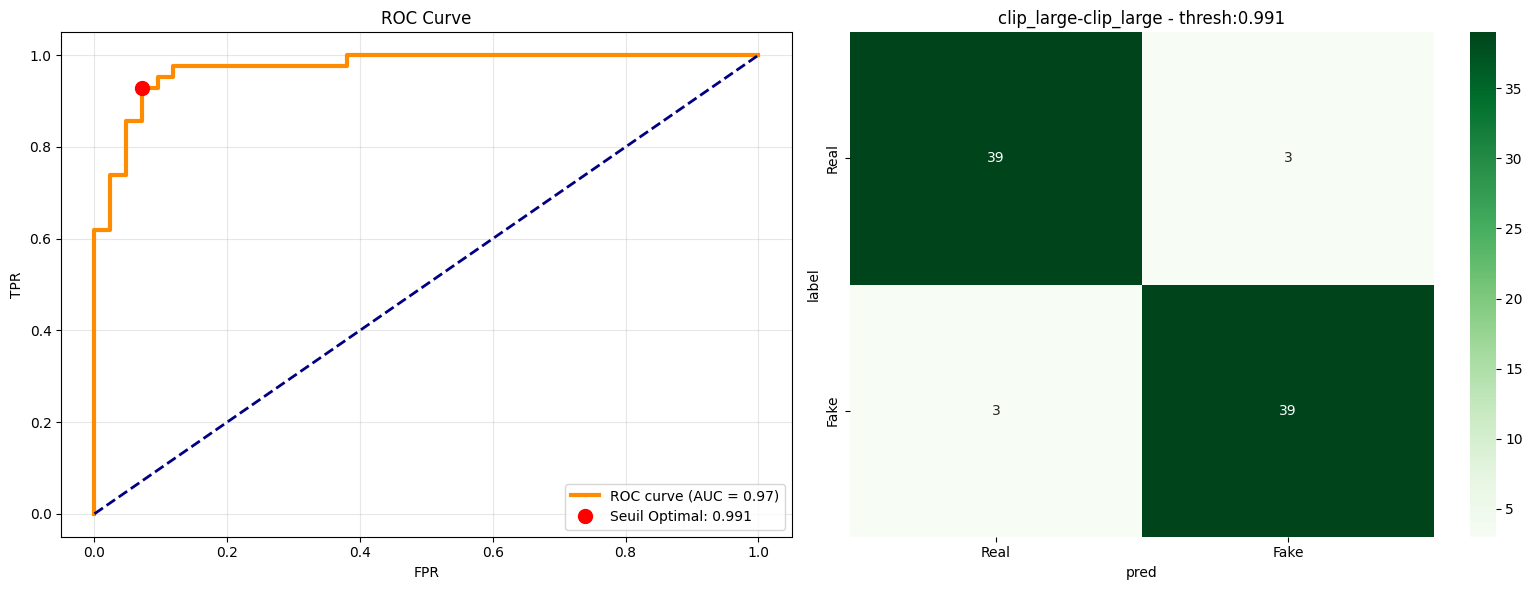

(AUC) : 0.8098
Threshold computed   : 0.9695
At threshold    : TPR=0.79, FPR=0.29
FNR=0.21


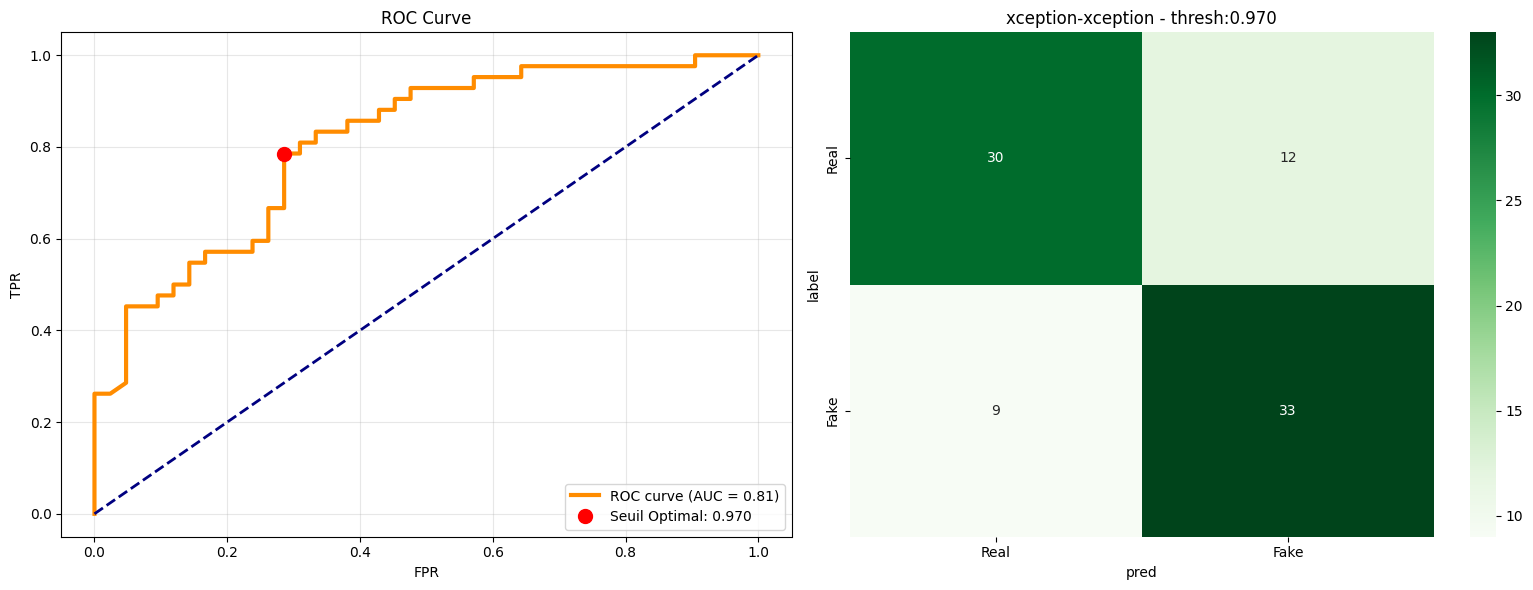

(AUC) : 0.9725
Threshold computed   : 0.9417
At threshold    : TPR=0.90, FPR=0.05
FNR=0.10


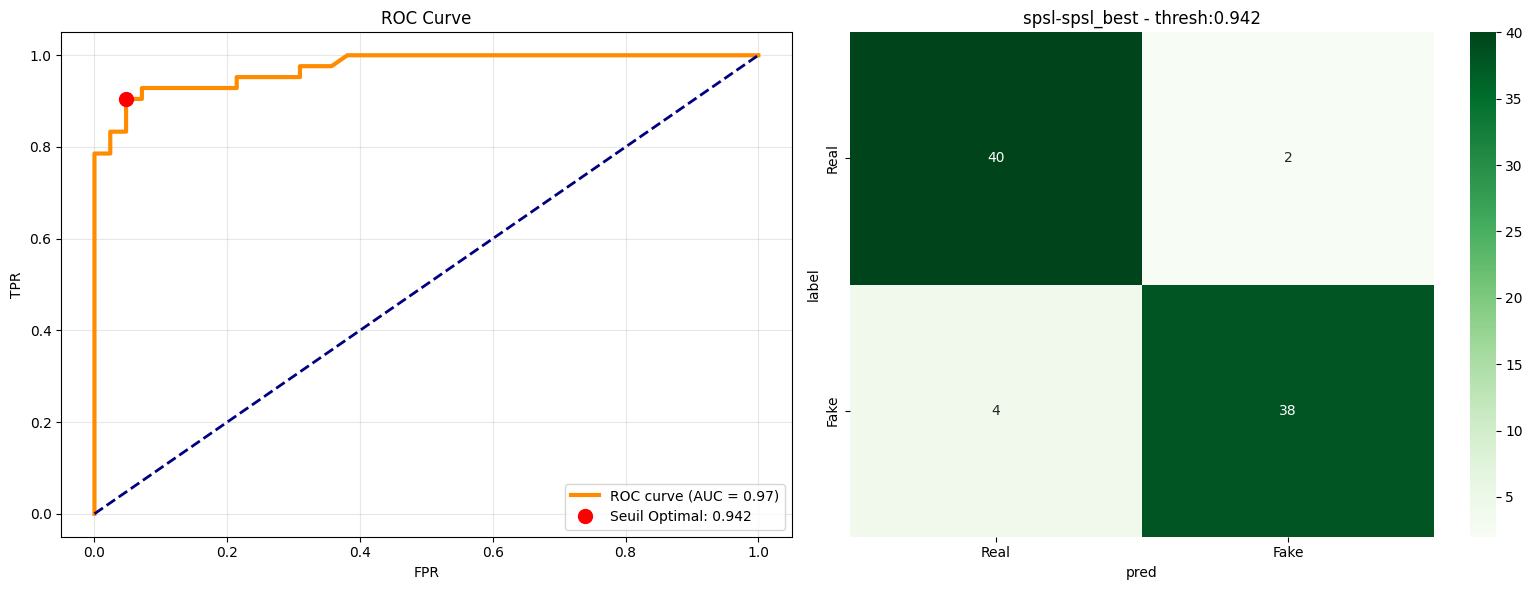

In [4]:
selected_models = [
    'recce-recce_best',
    'srm-srm_best',
    'xception-xception_best',
    'clip_base-clip',
    'clip_large-clip_large',
    'spsl-spsl_best',
    'ucf-ucf_best',
    'xception-xception',
    'effort-effort_ff_best'
    ]

for file in os.listdir("confdf_results_csv"):
    if file.replace(".csv", "") in selected_models:

        df_results = pd.read_csv(f"confdf_results_csv/{file}", index_col=0)

        plot_model_performance(df_results, file.replace(".csv", ""))

        #plot_model_performance_log(df_results, file.replace(".csv", ""))

        

        #display_roc_curve(df_results, file.replace(".csv", ""))
        #display_confusion_matrix(df_results, file.replace(".csv", ""))


In [ ]:
def plot_model_performance_log(df_video_preds, model_name):

    y_true = df_video_preds["label"]
    y_scores = df_video_preds["raw_pred_log"]

    # 1. Calcul de la courbe ROC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)

    # 2. CALCUL DU SEUIL OPTIMAL (Indice de Youden)
    # On cherche l'indice où la différence entre TPR et FPR est maximale
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"(AUC) : {roc_auc:.4f}")
    print(f"Threshold computed   : {optimal_threshold:.4f}")
    print(f"At threshold    : TPR={tpr[optimal_idx]:.2f}, FPR={fpr[optimal_idx]:.2f}")
    print(f"FNR={1-tpr[optimal_idx]:.2f}")
    # 3. Création des graphiques
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- GRAPH 1 : ROC CURVE ---
    ax1.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    # On marque le point optimal sur la courbe
    ax1.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
             label=f'Seuil Optimal: {optimal_threshold:.3f}')
    
    ax1.set_xlabel('FPR')
    ax1.set_ylabel('TPR')
    ax1.set_title('Courbe ROC avec Seuil Optimal LOG')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)

    # --- GRAPH 2 : CONFUSION MATRIX ---
    # On applique le seuil calculé pour obtenir les prédictions
    y_pred = [1 if s >= optimal_threshold else 0 for s in y_scores]
    cm = metrics.confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=['Réel', 'Fake'], yticklabels=['Réel', 'Fake'])
    
    ax2.set_xlabel('Prédictions (Seuil Optimal)')
    ax2.set_ylabel('Vérité Terrain')
    ax2.set_title(f'{model_name} - thresh:{optimal_threshold:.3f}')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_model_performance(df_video_preds, model_name):

    y_true = df_video_preds["label"]
    y_scores = df_video_preds["raw_pred_mean"]

    # 1. Calcul de la courbe ROC
    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_scores)
    roc_auc = metrics.auc(fpr, tpr)

    # 2. CALCUL DU SEUIL OPTIMAL (Indice de Youden)
    # On cherche l'indice où la différence entre TPR et FPR est maximale
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"(AUC) : {roc_auc:.4f}")
    print(f"Threshold computed   : {optimal_threshold:.4f}")
    print(f"At threshold    : TPR={tpr[optimal_idx]:.2f}, FPR={fpr[optimal_idx]:.2f}")
    print(f"FNR={1-tpr[optimal_idx]:.2f}")
    # 3. Création des graphiques
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- GRAPH 1 : ROC CURVE ---
    ax1.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    
    # On marque le point optimal sur la courbe
    ax1.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
             label=f'Youden threshold: {optimal_threshold:.3f}')
    
    ax1.set_xlabel('FPR')
    ax1.set_ylabel('TPR')
    ax1.set_title('ROC Curve')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)

    # --- GRAPH 2 : CONFUSION MATRIX ---
    # On applique le seuil calculé pour obtenir les prédictions
    y_pred = [1 if s >= optimal_threshold else 0 for s in y_scores]
    cm = metrics.confusion_matrix(y_true, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax2,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    
    ax2.set_xlabel('pred')
    ax2.set_ylabel('label')
    ax2.set_title(f'{model_name} - thresh:{optimal_threshold:.3f}')

    plt.tight_layout()
    plt.show()

In [75]:
def display_roc_curve(df_video_preds, model_name): 

    roc_log = metrics.roc_curve(df_video_preds["label"], df_video_preds["class_log"])

    fpr_log, tpr_log, threshold_log = roc_log
    roc_auc_log = metrics.auc(fpr_log, tpr_log)

    roc_mean = metrics.roc_curve(df_video_preds["label"], df_video_preds["class_mean"])

    fpr_mean, tpr_mean, threshold_mean = roc_mean
    roc_auc_mean = metrics.auc(fpr_mean, tpr_mean)

    roc_mean = metrics.roc_curve(df_video_preds["label"], df_video_preds["class_mean"])

    fpr_mean, tpr_mean, threshold_mean = roc_mean
    roc_auc_mean = metrics.auc(fpr_mean, tpr_mean)


    plt.figure(figsize=(8, 6))
        
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')

    plt.plot(fpr_log, tpr_log, color='darkorange', lw=3, 
                label=f'Logit (AUC = {roc_auc_log:.2f})')
    plt.plot(fpr_mean, tpr_mean, color='blue', lw=3, 
                label=f'Mean (AUC = {roc_auc_mean:.2f})')

    # Mise en forme
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('FP')
    plt.ylabel('VP')
    plt.title(model_name)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    plt.show()

In [76]:
def display_confusion_matrix(df_video_preds, model_name):

    cm = metrics.confusion_matrix(df_video_preds["label"], df_video_preds["class_mean"])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred real', 'Pred fake'],
                yticklabels=['Label real', 'Label fake'])

    plt.xlabel('Preds')
    plt.ylabel('Labels')
    plt.title(model_name)
    plt.show()